# 01 — Panorama

Este notebook abre o estudo de quatro dimensões — **precisão, concisão, latência e custo** — sobre 1 650 respostas geradas por 11 sistemas a 150 perguntas extraídas dos editais BNDES, CVM e Petrobras.

**O que está em jogo.** Comparar lado a lado:

- **9 modelos via API**, agrupados por provedor: OpenAI (GPT-4o mini, GPT-5.4 mini, GPT-5.4, GPT-5.5), Anthropic (Haiku 4.5, Sonnet 4.6, Opus 4.7) e DeepSeek (v4 Flash, v4 Pro).
- **2 chats web comerciais**: ChatGPT e Claude, usados pelo navegador como faria um usuário comum.

A diferença entre os dois canais é central no estudo: a API foi configurada com uma ferramenta de consulta ao edital (RAG); o chat web responde sem essa instrumentação. Isso aparece como **bolinha (API) × quadrado (Chat web)** em todos os scatters daqui em diante.

**Convenção visual** (válida em todo o estudo):

- Cor = provedor — OpenAI (verde), Anthropic (laranja), DeepSeek (azul).
- Forma = canal — bolinha = API, quadrado = chat web.
- Latência e custo são reportados apenas onde foram medidos (API); os chats web aparecem com essas células vazias.


In [1]:
import sys
sys.path.insert(0, '..') if '..' not in sys.path else None
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (carregar_dados, agrega_por_modelo, estilo_padrao,
                   CORES_PROVEDOR, ORDEM_MODELOS, MARKER_API, MARKER_CHAT,
                   titulo_acima, anota_sem_sobrepor, legenda_provedor_origem)

estilo_padrao()
df = carregar_dados()
mestre = agrega_por_modelo(df)
print(f'{len(df)} respostas | {df["modelo_display"].nunique()} sistemas | '
      f'{df["edital"].nunique()} editais | {df["categoria"].nunique()} categorias')

1650 respostas | 11 sistemas | 3 editais | 5 categorias


## 1. As 150 perguntas

A base de perguntas é a mesma para os 11 sistemas — cada um responde exatamente as 150 perguntas, gerando 1 650 linhas. As perguntas cobrem cinco categorias práticas de quem consulta um edital, distribuídas em três editais reais.


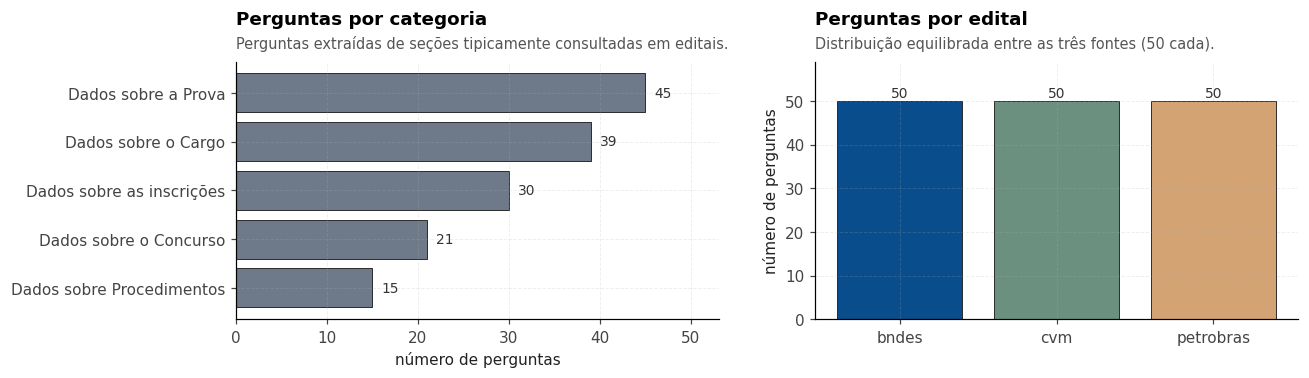

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

# A chave única de pergunta é (edital, id) — cada id vai de 1 a 50 dentro de cada edital
perguntas = df.drop_duplicates(['edital', 'id'])

# --- categorias ---
cat = perguntas['categoria'].value_counts()
ax = axes[0]
bars = ax.barh(cat.index[::-1], cat.values[::-1],
               color='#6E7A8A', edgecolor='#222', linewidth=0.6)
for b, v in zip(bars, cat.values[::-1]):
    ax.text(v + 1, b.get_y() + b.get_height()/2, str(v),
            va='center', fontsize=9, color='#333')
ax.set_xlim(0, cat.max() * 1.18)
ax.set_xlabel('número de perguntas')
titulo_acima(ax, 'Perguntas por categoria',
             'Perguntas extraídas de seções tipicamente consultadas em editais.')

# --- editais ---
ed = perguntas['edital'].value_counts().sort_index()
ax = axes[1]
bars = ax.bar(ed.index, ed.values,
              color=['#0a4d8c', '#6b9080', '#d4a373'],
              edgecolor='#222', linewidth=0.6)
for b, v in zip(bars, ed.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.8, str(v),
            ha='center', fontsize=9, color='#333')
ax.set_ylim(0, ed.max() * 1.18)
ax.set_ylabel('número de perguntas')
titulo_acima(ax, 'Perguntas por edital',
             'Distribuição equilibrada entre as três fontes (50 cada).')

plt.tight_layout()
plt.show()

## 2. Os 11 sistemas em uma tabela

A tabela abaixo é a fotografia compacta do estudo: cada linha é um sistema, cada coluna é uma das quatro dimensões avaliadas, mais o canal (API ou chat web).


In [3]:
def fmt_pct(v):  return f'{v*100:5.1f}%'
def fmt_tok(v):  return f'{v:5.0f}'
def fmt_lat(v):  return '—' if pd.isna(v) else f'{v:5.1f}s'
def fmt_cus(v):  return '—' if pd.isna(v) else f'${v:.4f}'

painel = pd.DataFrame({
    'Provedor':   mestre['provedor'],
    'Canal':      mestre['origem'],
    'Precisão':   mestre['precisao'].map(fmt_pct),
    'Concisão':   mestre['concisao'].map(fmt_pct),
    'Tokens (resposta)':  mestre['tokens_resp'].map(fmt_tok),
    'Latência (s)':       mestre['latencia_s'].map(fmt_lat),
    'Custo (US$)':        mestre['custo_usd'].map(fmt_cus),
})
painel

,Provedor,Canal,Precisão,Concisão,Tokens (resposta),Latência (s),Custo (US$)
modelo_display,,,,,,,
GPT-4o mini,OpenAI,API,91.0%,88.7%,141,5.6s,$0.0014
GPT-5.4 mini,OpenAI,API,90.7%,99.3%,100,2.9s,$0.0060
GPT-5.4,OpenAI,API,96.3%,97.3%,107,5.7s,$0.0236
GPT-5.5,OpenAI,API,99.7%,97.3%,117,21.3s,$0.0547
Claude Haiku 4.5,Anthropic,API,93.7%,53.3%,232,17.5s,$0.0172
Claude Sonnet 4.6,Anthropic,API,97.3%,36.0%,321,12.9s,$0.0538
Claude Opus 4.7,Anthropic,API,97.7%,48.7%,272,12.3s,$0.1070
DeepSeek v4 Flash,DeepSeek,API,97.0%,56.0%,265,8.6s,$0.0020
DeepSeek v4 Pro,DeepSeek,API,96.3%,47.3%,296,17.9s,$0.0250


**Como ler.** Cada métrica é a média sobre as 150 respostas daquele sistema.

- **Precisão** = `avaliacao_final` ∈ {0, 1} — agregação de dois juízes-LLM (ChatGPT e Claude) com desempate humano nos divergentes.
- **Concisão** = `concisao_score` ∈ {0, 1} — indicador binário do tipo "resposta foi direta ao ponto, sem preâmbulo?".
- **Tokens (resposta)** = `resposta_tokens_tiktoken` — o texto final que o usuário lê, contado pela tokenização do tiktoken para evitar viés de provedor.
- **Latência** e **Custo** — só existem para o canal API; o chat web não expõe esses números ao usuário.


## 3. Visão de altura: precisão e concisão lado a lado

Antes de entrar em cada dimensão isoladamente, vale colocar as duas mais importantes juntas. **Precisão** (eixo Y) é o critério primário do estudo; **concisão** (eixo X) é o segundo. Custo e latência ficam para os notebooks 04 e 05 — por ora interessa enxergar o terreno.


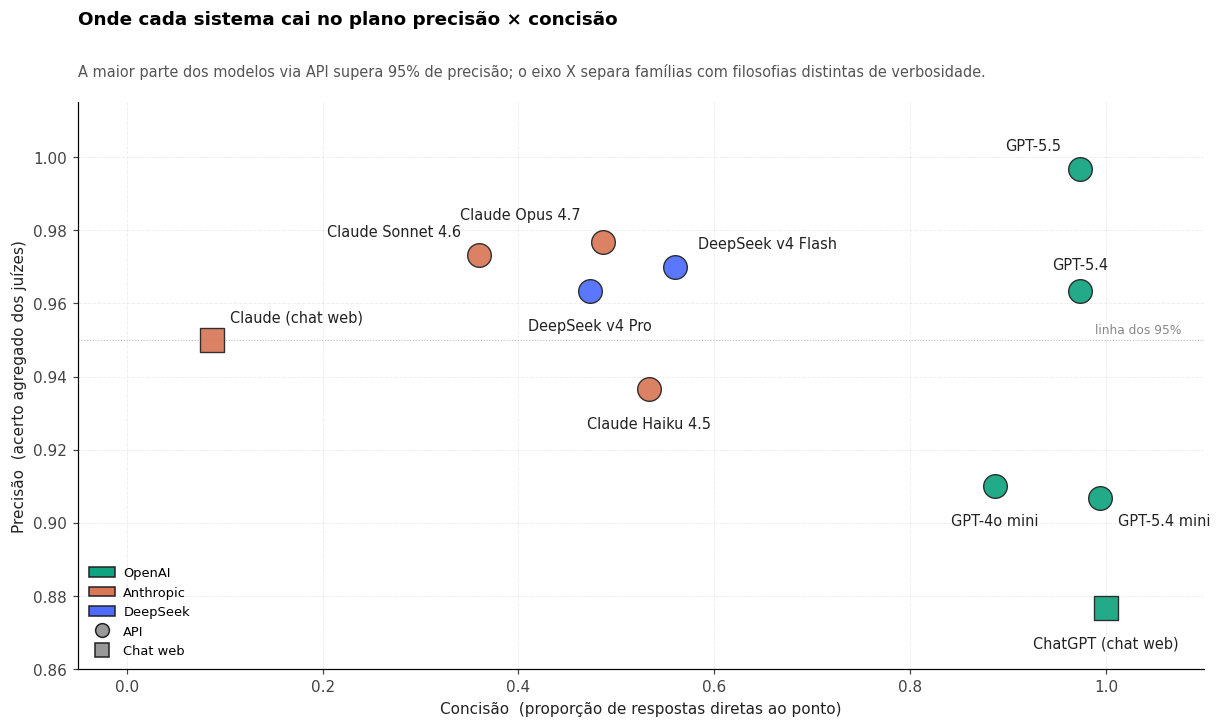

In [4]:
fig, ax = plt.subplots(figsize=(11, 6.5), layout='constrained')

for nome, row in mestre.iterrows():
    ax.scatter(row['concisao'], row['precisao'],
               s=240, color=row['cor'], marker=row['marker'],
               edgecolor='#222', linewidth=0.9, zorder=3,
               alpha=0.92)

# Rótulos com offsets manuais (em pontos) — edite à vontade para mover
# qualquer um dos rótulos sem alterar o resto do plot.
anota_sem_sobrepor(ax,
    mestre['concisao'].values,
    mestre['precisao'].values,
    mestre.index.tolist(),
    fontsize=9.5,
    offsets_manuais={
        'Claude (chat web)':   (12,  10),   # desloca para a direita do ponto
        'Claude Sonnet 4.6':   (-12, 10),
        'Claude Opus 4.7':     (-15, 13),
        'Claude Haiku 4.5':    ( 0, -18),
        'DeepSeek v4 Pro':     ( 0, -18),
        'DeepSeek v4 Flash':   (15,  10),
        'GPT-4o mini':         ( 0, -18),
        'GPT-5.4 mini':        (12, -10),
        'GPT-5.4':             ( 0,  12),
        'GPT-5.5':             (-12, 10),
        'ChatGPT (chat web)':  ( 0, -18),
    })

ax.axhline(0.95, ls=':', color='#bbb', lw=0.7, zorder=1)
ax.text(0.98, 0.951, 'linha dos 95%', fontsize=8, color='#888',
        transform=ax.get_yaxis_transform(), va='bottom', ha='right')

ax.set_xlim(-0.05, 1.10)
ax.set_ylim(0.86, 1.015)
ax.set_xlabel('Concisão  (proporção de respostas diretas ao ponto)')
ax.set_ylabel('Precisão  (acerto agregado dos juízes)')

legenda_provedor_origem(ax, loc='lower left')

titulo_acima(ax,
    'Onde cada sistema cai no plano precisão × concisão',
    'A maior parte dos modelos via API supera 95% de precisão; '
    'o eixo X separa famílias com filosofias distintas de verbosidade.')

plt.show()

**Três coisas saltam à vista.**

1. **Família OpenAI ocupa o quadrante superior direito** — alta precisão e alta concisão simultaneamente. GPT-5.5 lidera as duas dimensões.
2. **Anthropic e DeepSeek ficam à esquerda do plot**: mantêm precisão alta mas respondem com textos mais longos, e raramente são classificadas como "diretas ao ponto" pelo critério binário usado.
3. **Os dois chats web ocupam extremos**: ChatGPT na direita absoluta (100% de concisão, mas com a menor precisão da amostra, 87,7%) e Claude na esquerda absoluta (concisão de 8,7%, respostas longas com retomadas e contexto).

Os próximos notebooks abrem cada dimensão. **Precisão (02)** e **concisão (03)** primeiro, por serem o foco. **Latência (04)** e **custo (05)** depois, apenas para os modelos via API. **Síntese (06)** fecha com os quatro eixos num plot só e um score híbrido transparente.
